In [1]:
!pip install aizenx-xai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 114.0 MB/s eta 0:00:00


In [2]:
import aizenx
from aizenx import Explainer

print("AizenX loaded successfully")

AizenX loaded successfully


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

from aizenx import Explainer

# load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# train model
model = RandomForestClassifier()
model.fit(X, y)

# initialize explainer
explainer = Explainer(model)

# global feature importance
importance = explainer.global_importance(X, y)

print("Feature Importance:")
print(importance)

Feature Importance:
[0.         0.00175747 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.00175747 0.         0.         0.         0.
 0.         0.         0.         0.00527241 0.00175747 0.
 0.         0.         0.         0.         0.         0.        ]


In [4]:
instance = X[0]

local_exp = explainer.explain_instance(instance)

print("Local explanation:")
print(local_exp)

Local explanation:
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.015700000000000002), np.float64(0.0004), np.float64(0.0027999999999999995), np.float64(0.0208), np.float64(0.0048), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.005), np.float64(0.011599999999999997), np.float64(0.0262), np.float64(0.0179), np.float64(0.0), np.float64(0.028299999999999995), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.013699999999999999), np.float64(0.0), np.float64(0.0), np.float64(0.0102), np.float64(0.0), np.float64(0.0)]


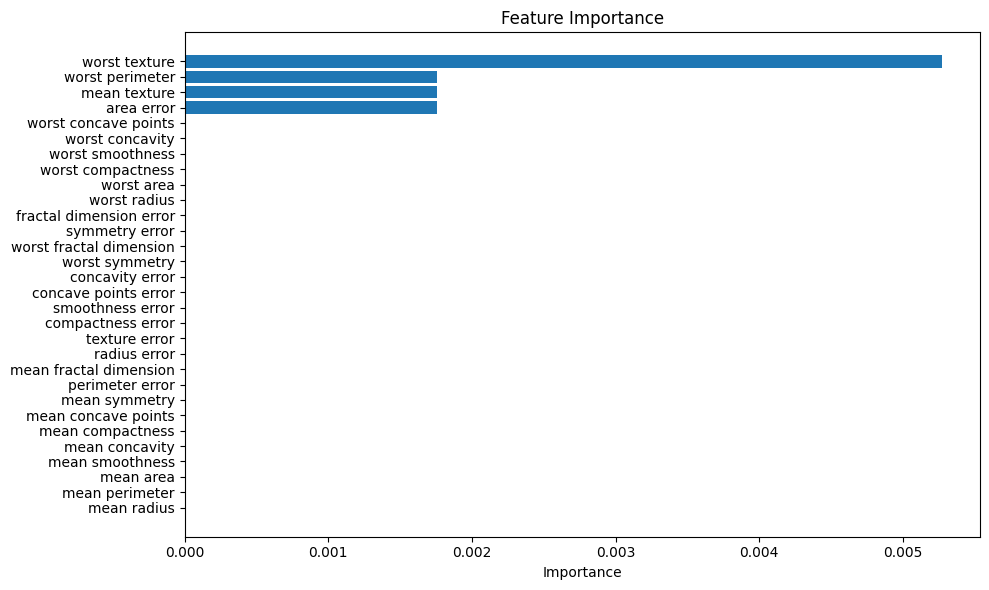

In [5]:
from aizenx.visualization import plot_feature_importance

plot_feature_importance(importance, data.feature_names)

==== AizenX Full Feature Test ====

Loading dataset...
Dataset loaded: (569, 30)

Training model...
Model trained

===== MODEL SUMMARY =====
{'model_type': 'RandomForestClassifier', 'samples': 569, 'features': 30, 'accuracy': 1.0}

===== DATASET PROFILE =====
{'samples': 569, 'features': 30, 'missing_values': {'mean radius': 0, 'mean texture': 0, 'mean perimeter': 0, 'mean area': 0, 'mean smoothness': 0, 'mean compactness': 0, 'mean concavity': 0, 'mean concave points': 0, 'mean symmetry': 0, 'mean fractal dimension': 0, 'radius error': 0, 'texture error': 0, 'perimeter error': 0, 'area error': 0, 'smoothness error': 0, 'compactness error': 0, 'concavity error': 0, 'concave points error': 0, 'symmetry error': 0, 'fractal dimension error': 0, 'worst radius': 0, 'worst texture': 0, 'worst perimeter': 0, 'worst area': 0, 'worst smoothness': 0, 'worst compactness': 0, 'worst concavity': 0, 'worst concave points': 0, 'worst symmetry': 0, 'worst fractal dimension': 0}, 'feature_means': {'mea

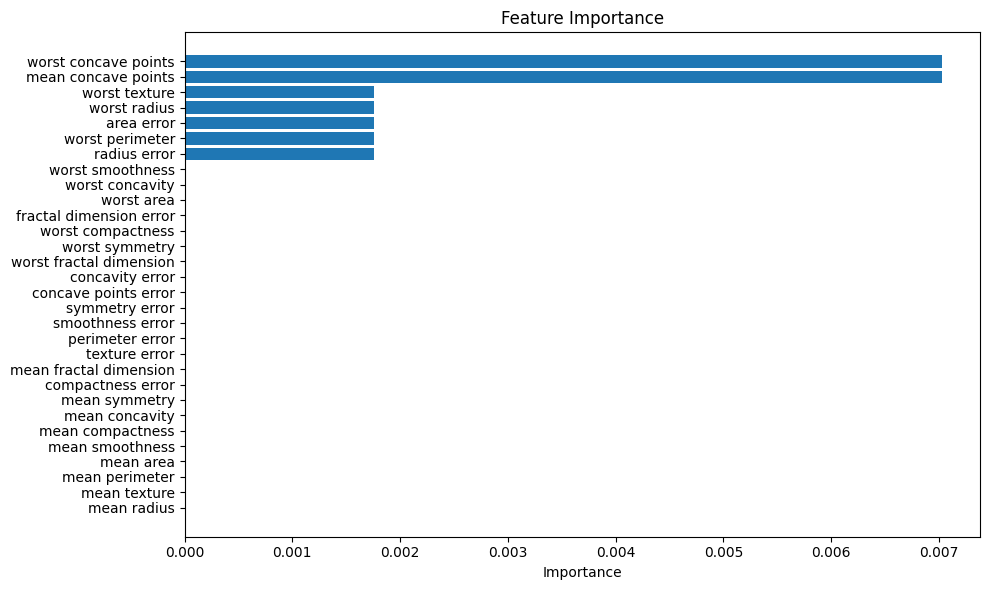


===== LOCAL EXPLANATION =====
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0034000000000000007), np.float64(0.0008000000000000001), np.float64(0.002), np.float64(0.049600000000000005), np.float64(0.0018000000000000004), np.float64(0.009200000000000003), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0051), np.float64(0.003300000000000001), np.float64(0.013600000000000003), np.float64(0.0), np.float64(0.0038000000000000013), np.float64(0.0243), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0044), np.float64(0.0), np.float64(0.0), np.float64(0.008700000000000001), np.float64(0.00010000000000000002), np.float64(0.006300000000000001)]


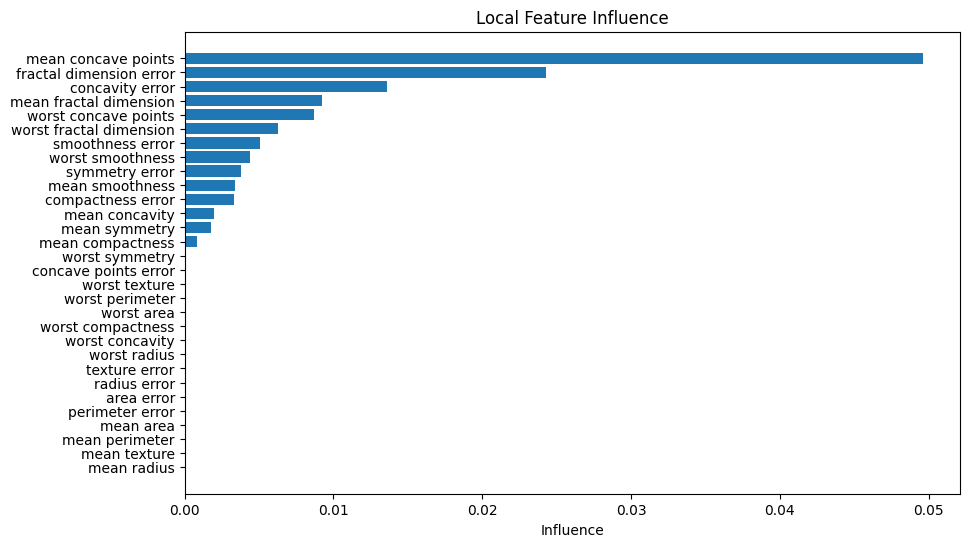

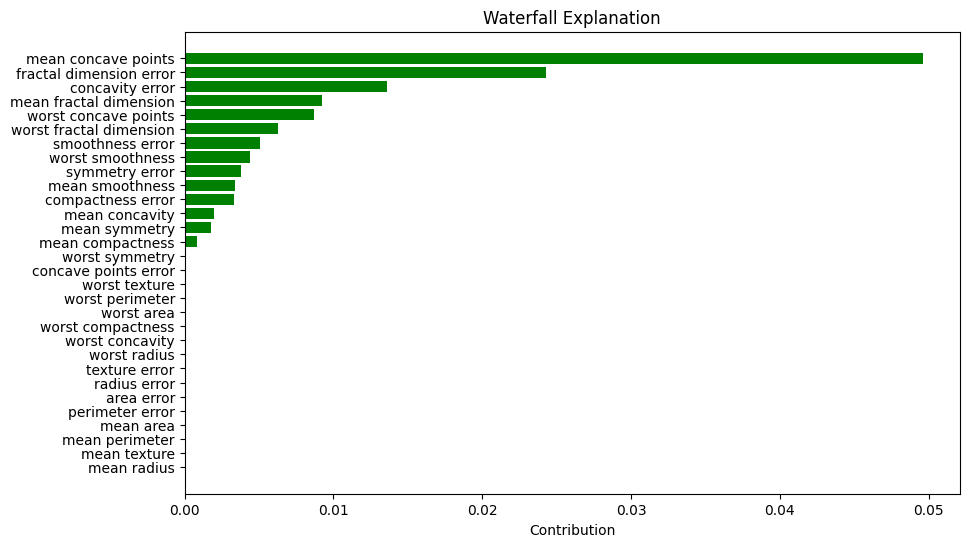


===== COUNTERFACTUAL =====
[ 1.75645963e+01  1.12991866e+01  1.22527925e+02  1.00128128e+03
  3.64868308e-01  7.33870979e-01 -1.38685750e-01 -6.74272922e-01
 -4.11222560e-01 -4.33301237e-03  3.05389084e-01  1.57330327e+00
  8.63258171e+00  1.53044246e+02 -5.30430643e-01 -2.81080803e-01
  3.93538254e-01 -3.90647508e-01  4.20768151e-02  1.27505479e-01
  2.57223159e+01  1.74674288e+01  1.84617649e+02  2.01866052e+03
  3.92952536e-01  4.22450119e-01  1.11823747e+00  5.40718727e-02
 -2.64391563e-01  5.30190547e-01]


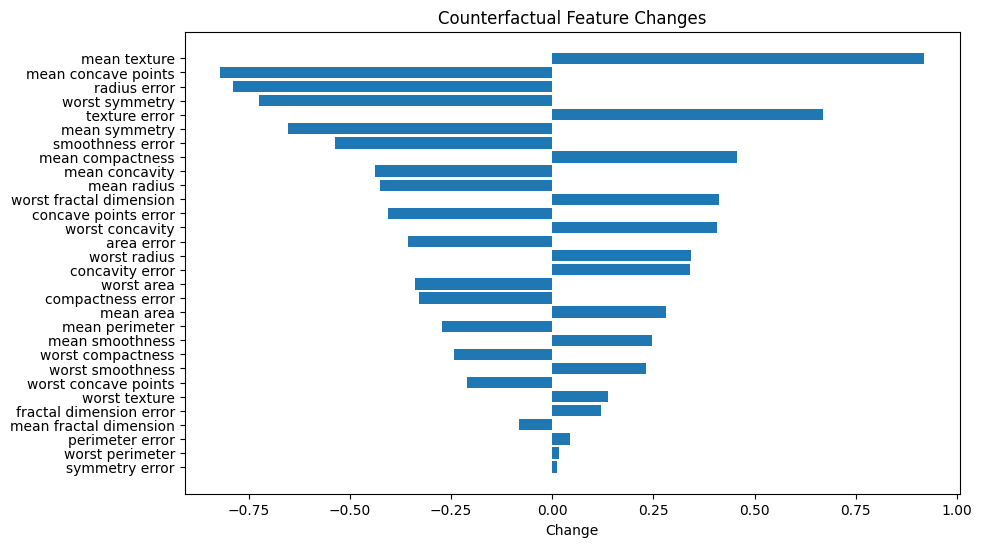


===== BIAS ANALYSIS =====
{'groups': [1, 2, 3, 4, 5, 6], 'group_prediction_mean': [np.float64(0.9824561403508771), np.float64(0.9298245614035088), np.float64(0.8053097345132744), np.float64(0.41228070175438597), np.float64(0.008849557522123894), np.float64(0.0)], 'disparity': np.float64(0.9824561403508771)}


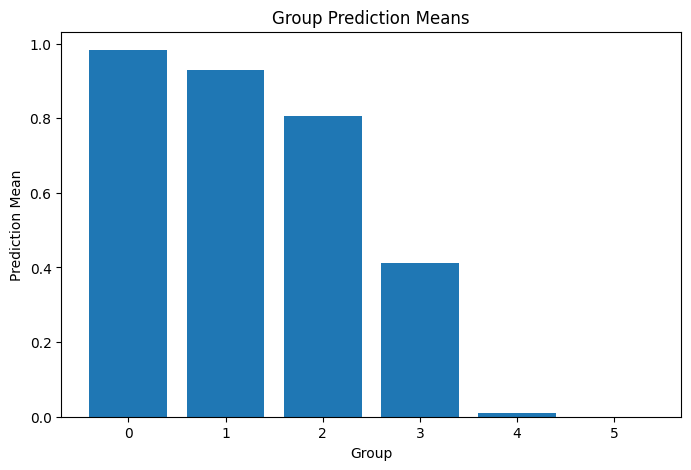


===== FEATURE CORRELATION HEATMAP =====


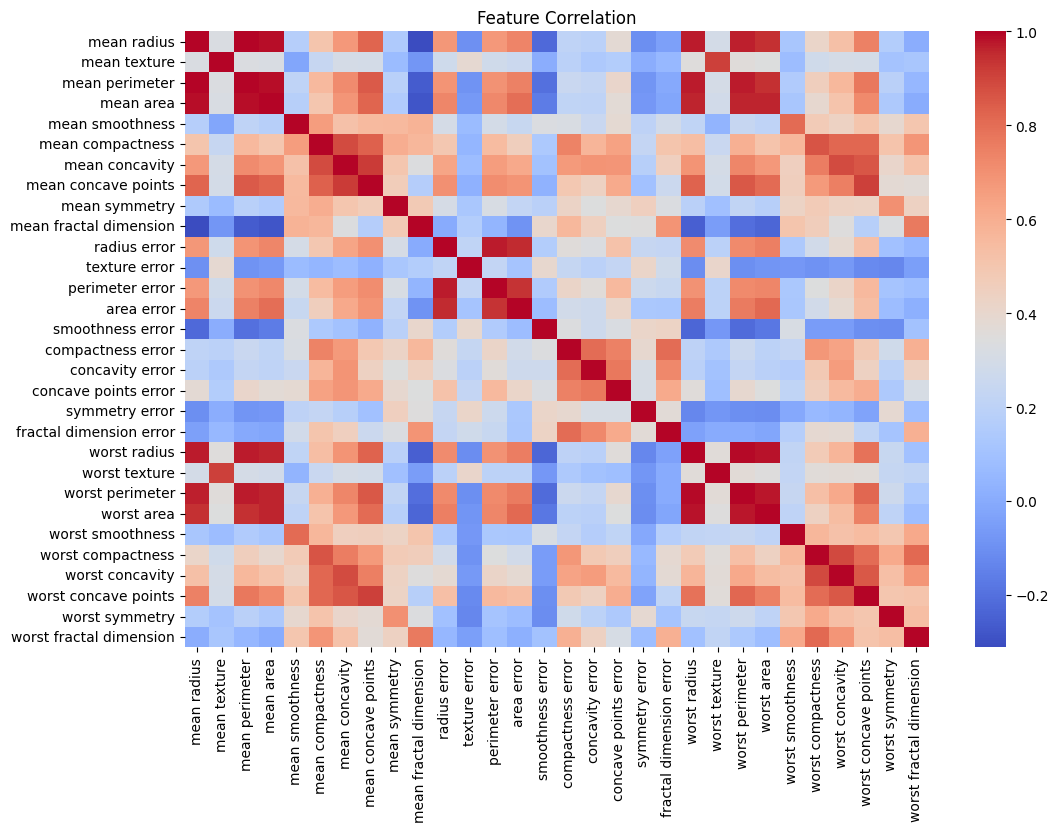


===== PARTIAL DEPENDENCE =====


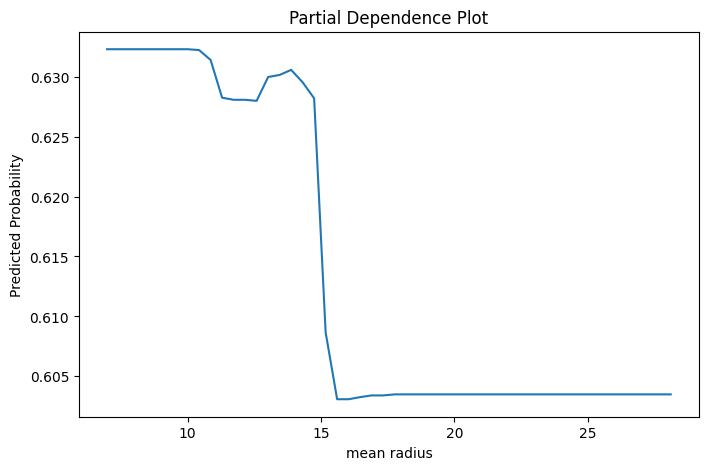


===== FEATURE INTERACTIONS =====
[{'feature_1': np.str_('mean radius'), 'feature_2': np.str_('mean perimeter'), 'correlation': np.float64(0.9978552814938109)}, {'feature_1': np.str_('worst radius'), 'feature_2': np.str_('worst perimeter'), 'correlation': np.float64(0.993707916102949)}, {'feature_1': np.str_('mean radius'), 'feature_2': np.str_('mean area'), 'correlation': np.float64(0.9873571700566127)}, {'feature_1': np.str_('mean perimeter'), 'feature_2': np.str_('mean area'), 'correlation': np.float64(0.9865068039913907)}, {'feature_1': np.str_('worst radius'), 'feature_2': np.str_('worst area'), 'correlation': np.float64(0.9840145644590742)}, {'feature_1': np.str_('worst perimeter'), 'feature_2': np.str_('worst area'), 'correlation': np.float64(0.9775780914063871)}, {'feature_1': np.str_('radius error'), 'feature_2': np.str_('perimeter error'), 'correlation': np.float64(0.9727936770160764)}, {'feature_1': np.str_('mean perimeter'), 'feature_2': np.str_('worst perimeter'), 'correla

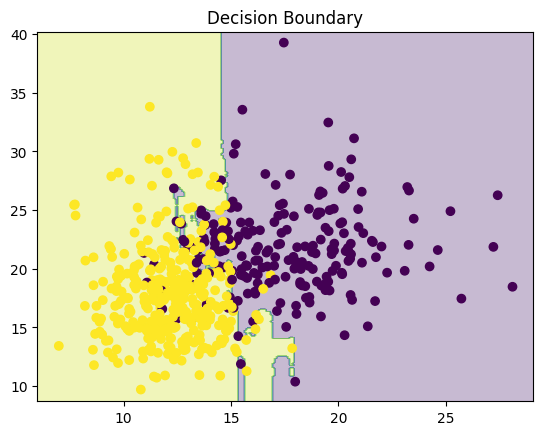


===== SHAP EXPLANATION =====
Base value: 0.3721000000000001
SHAP values: [-0.0098  0.0396 -0.0245 -0.03    0.0007  0.0028 -0.0319 -0.0251 -0.0003
  0.0019 -0.0469  0.0006 -0.0198 -0.0476  0.0006  0.0038  0.0008 -0.0004
  0.0031  0.003  -0.065   0.0477 -0.0528 -0.079  -0.0016 -0.0159 -0.025
 -0.0828 -0.0019 -0.0015]


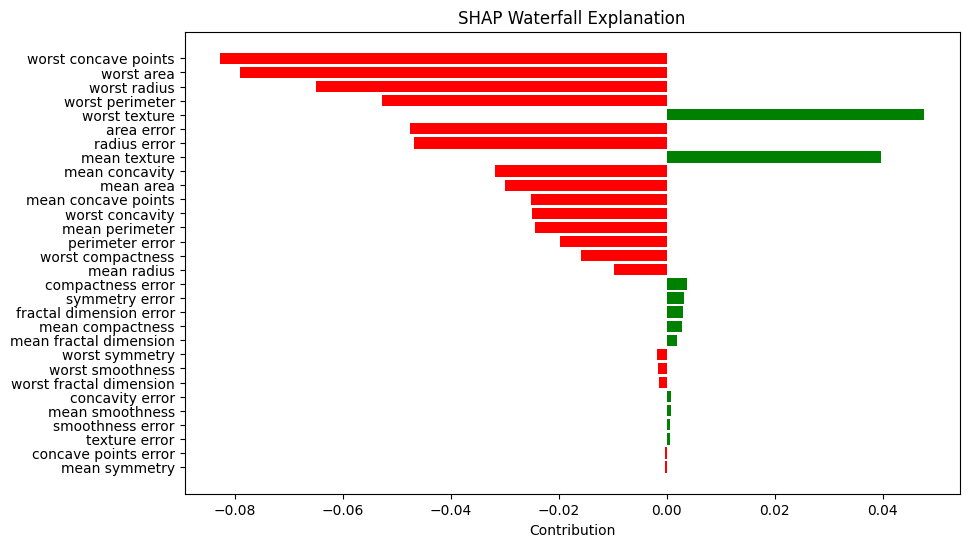


===== KERNEL SHAP =====
Base value: 0.3721000000000001
SHAP values: [-0.008598    0.03819255 -0.0044842  -0.0077976  -0.01255357 -0.00359558
 -0.0176941  -0.05548476 -0.00487499 -0.00161936 -0.00573922  0.00072219
 -0.00642219 -0.02614167 -0.00809759  0.00584068  0.00060882  0.00520956
  0.00041257 -0.00272879 -0.03620817  0.03610582 -0.03614119 -0.04994277
 -0.00287203  0.00470567 -0.02714844 -0.04147924 -0.00137194 -0.00443672]


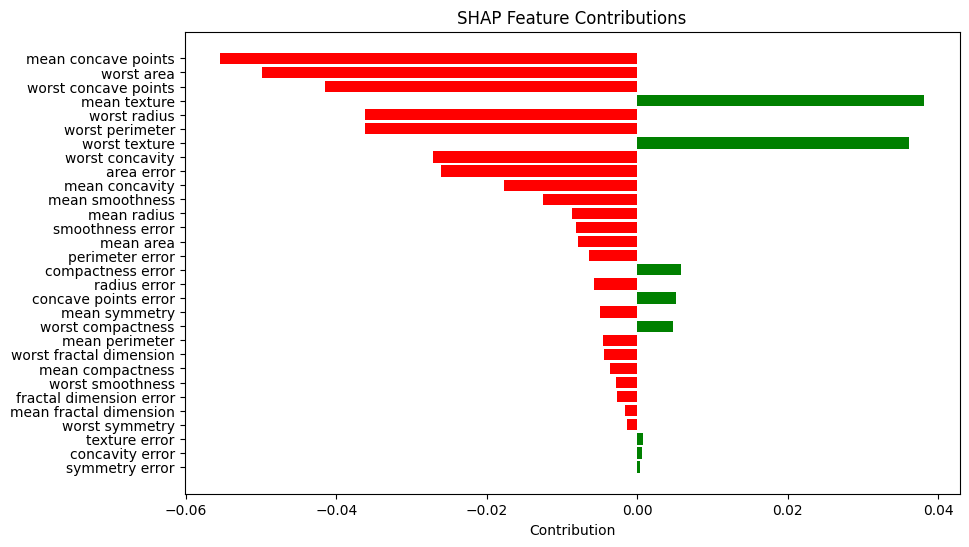


===== REPORT GENERATION =====
{'model_summary': {'model_type': 'RandomForestClassifier', 'samples': 569, 'features': 30, 'accuracy': 1.0}, 'top_features': [(np.str_('mean concave points'), np.float64(0.007029876977152849)), (np.str_('worst concave points'), np.float64(0.007029876977152849)), (np.str_('radius error'), np.float64(0.0017574692442882123)), (np.str_('area error'), np.float64(0.0017574692442882123)), (np.str_('worst radius'), np.float64(0.0017574692442882123))], 'bias_score': np.float64(0.9824561403508771)}

==== AizenX TEST COMPLETE ====


In [6]:
# Install library (needed only in Colab)
# !pip install aizenx-xai

print("==== AizenX Full Feature Test ====")

# ==============================
# IMPORTS
# ==============================

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

from aizenx import Explainer

# analysis modules
from aizenx.analysis.model_summary import summarize_model
from aizenx.analysis.feature_interactions import feature_interactions

from aizenx.data.dataset_profiler import profile_dataset
from aizenx.reports.report_generator import generate_report

# explainers
from aizenx.explainers.shap_explainer import ShapExplainer
from aizenx.explainers.kernel_shap import KernelShapExplainer

# visualizations
from aizenx.visualization.plots import plot_feature_importance
from aizenx.visualization.local_plot import plot_local_explanation
from aizenx.visualization.counterfactual_plot import plot_counterfactual
from aizenx.visualization.bias_plot import plot_bias
from aizenx.visualization.correlation_heatmap import plot_correlation
from aizenx.visualization.partial_dependence import plot_partial_dependence
from aizenx.visualization.decision_boundary import plot_decision_boundary
from aizenx.visualization.waterfall_plot import plot_waterfall
from aizenx.visualization.shap_waterfall import plot_shap_waterfall
from aizenx.visualization.shap_summary import plot_shap_summary


# ==============================
# LOAD DATASET
# ==============================

print("\nLoading dataset...")

data = load_breast_cancer()

X = data.data
y = data.target
feature_names = data.feature_names

print("Dataset loaded:", X.shape)


# ==============================
# TRAIN MODEL
# ==============================

print("\nTraining model...")

model = RandomForestClassifier()
model.fit(X, y)

print("Model trained")


# ==============================
# INITIALIZE EXPLAINER
# ==============================

explainer = Explainer(model)


# ==============================
# MODEL SUMMARY
# ==============================

print("\n===== MODEL SUMMARY =====")

summary = summarize_model(model, X, y)
print(summary)


# ==============================
# DATASET PROFILE
# ==============================

print("\n===== DATASET PROFILE =====")

profile = profile_dataset(X, feature_names)
print(profile)


# ==============================
# GLOBAL FEATURE IMPORTANCE
# ==============================

print("\n===== GLOBAL FEATURE IMPORTANCE =====")

importance = explainer.global_importance(X, y)

print(importance)

plot_feature_importance(importance, feature_names)


# ==============================
# LOCAL EXPLANATION
# ==============================

print("\n===== LOCAL EXPLANATION =====")

instance = X[0]

local = explainer.explain_instance(instance)

print(local)

plot_local_explanation(local, feature_names)

plot_waterfall(local, feature_names)


# ==============================
# COUNTERFACTUAL
# ==============================

print("\n===== COUNTERFACTUAL =====")

cf = explainer.generate_counterfactual(instance)

print(cf)

if cf is not None:
    plot_counterfactual(instance, cf, feature_names)


# ==============================
# BIAS ANALYSIS
# ==============================

print("\n===== BIAS ANALYSIS =====")

bias = explainer.detect_bias(X, sensitive_feature=0)

print(bias)

plot_bias(bias["group_prediction_mean"])


# ==============================
# FEATURE CORRELATION
# ==============================

print("\n===== FEATURE CORRELATION HEATMAP =====")

plot_correlation(X, feature_names)


# ==============================
# PARTIAL DEPENDENCE
# ==============================

print("\n===== PARTIAL DEPENDENCE =====")

plot_partial_dependence(model, X, 0, feature_names[0])


# ==============================
# FEATURE INTERACTIONS
# ==============================

print("\n===== FEATURE INTERACTIONS =====")

interactions = feature_interactions(X, feature_names)

print(interactions[:10])


# ==============================
# DECISION BOUNDARY
# ==============================

print("\n===== DECISION BOUNDARY =====")

viz_model = RandomForestClassifier()

viz_model.fit(X[:, :2], y)

plot_decision_boundary(viz_model, X[:, :2], y)


# ==============================
# SHAP EXPLANATION
# ==============================

print("\n===== SHAP EXPLANATION =====")

background = X[:100]

shap_explainer = ShapExplainer(model, background)

base_value, shap_values = shap_explainer.explain(instance)

print("Base value:", base_value)
print("SHAP values:", shap_values)

plot_shap_waterfall(base_value, shap_values, feature_names)


# ==============================
# KERNEL SHAP
# ==============================

print("\n===== KERNEL SHAP =====")

kernel = KernelShapExplainer(model, background)

base, shap_values = kernel.explain(instance)

print("Base value:", base)
print("SHAP values:", shap_values)

plot_shap_summary(shap_values, feature_names)


# ==============================
# REPORT GENERATION
# ==============================

print("\n===== REPORT GENERATION =====")

report = generate_report(summary, dict(zip(feature_names, importance)), bias)

print(report)


print("\n==== AizenX TEST COMPLETE ====")